# Miscellaneous

> Miscellaneous utilities for the multigrid environment

In [ ]:
#| default_exp utils.misc

In [ ]:
#| hide
from nbdev.showdoc import *

In [2]:
#| export
from typing import Any
import numpy as np

In [3]:
#| export

class PropertyAlias(property):
    """
    A class property that is an alias for an attribute property.

    Instead of::

        @property
        def x(self):
            self.attr.x

        @x.setter
        def x(self, value):
            self.attr.x = value

    we can simply just declare::

        x = PropertyAlias('attr', 'x')
    """

    def __init__(self, attr_name: str, attr_property_name: str, doc: str = None) -> None:
        """
        Parameters
        ----------
        attr_name : str
            Name of the base attribute
        attr_property : property
            Property from the base attribute class
        doc : str
            Docstring to append to the property's original docstring
        """
        prop = lambda obj: getattr(type(getattr(obj, attr_name)), attr_property_name)
        fget = lambda obj: prop(obj).fget(getattr(obj, attr_name))
        fset = lambda obj, value: prop(obj).fset(getattr(obj, attr_name), value)
        fdel = lambda obj: prop(obj).fdel(getattr(obj, attr_name))
        super().__init__(fget, fset, fdel, doc=doc)
        self.__doc__ = doc


In [ ]:
#| export
CELL_SIZE = 2.0   # metres per grid cell
WALL_H    = 3.0   # only needed if you want the vertical center

def grid_to_world(gx: int, gy: int, cell_size: float = CELL_SIZE):
    """
    Map a 2D grid cell (gx, gy) to the 3D world position (wx, wy, wz).
    
    - wx = gx * cell_size           (grid x -> world y, same direction)
    - wy = -gy * cell_size          (grid y -> world x, FLIPPED because
                                     Blender Y is forward but grid Y is down)
    - wz = 1.0                      (up-ground level, agents walk on z=1)
    """
    wx = gx * cell_size
    wy = -gy * cell_size   # flip Y
    wz = 1.0
    return [wx, wy, wz]

def world_to_grid(wx: float, wy: float, cell_size: float = CELL_SIZE):
    """
    Inverse: map a continuous 3D world position back to the nearest grid cell.
    """
    gx = int(round(wx / cell_size))
    gy = int(round(-wy / cell_size))   # un-flip Y
    return [gx, gy]


In [20]:
#| export

def valid_positions(grid: np.ndarray) -> list[tuple[int, int]]:
    """
    Return a list of valid (gx, gy) positions in the grid.
    A position is valid if grid.get(gx, gy).type is not 'wall'.
    """
    valid = []
    for gx in range(grid.height):
        for gy in range(grid.width):
            
            if grid.get(gx, gy) and grid.get(gx, gy).type == 'wall':
                continue
            valid.append((gx, gy))
    return valid


def get_lst_world_positions(grid: np.ndarray) -> list[tuple[float, float, float]]:
    """
    Return a list of world positions corresponding to the valid grid positions.
    """
    valid = valid_positions(grid)
    return [grid_to_world(gx, gy) for gx, gy in valid]

In [21]:
#| hide
import gymnasium as gym
import multigrid.envs
env = gym.make('MultiGrid-FindGoal-15x15-v0', 
               agents=2, 
               render_mode='rgb_array', 
               num_obstacles=6, 
               width=15, 
               height=15)
obs, info = env.reset(seed= 0)


Rejecting spawn positions too close to goal
Goal pos: (np.int64(4), np.int64(13)), Candidate pos: (np.int64(5), np.int64(5))
Rejecting spawn positions too close to goal
Goal pos: (np.int64(4), np.int64(13)), Candidate pos: (np.int64(6), np.int64(7))


In [22]:
#| hide
valid_2d = valid_positions(env.unwrapped.grid)                         
world_positions = get_lst_world_positions(env.unwrapped.grid)

N = len(valid_2d)


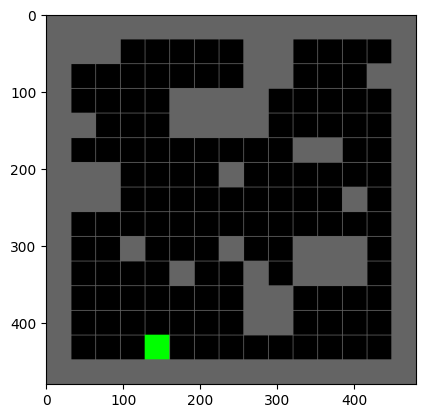

In [23]:
#| hide
import matplotlib.pyplot as plt
grid_img = env.unwrapped.get_layout()
plt.imshow(grid_img)
plt.show()

In [24]:
#| hide
env.unwrapped.goal_pos

(np.int64(4), np.int64(13))

In [25]:
#| hide
env.unwrapped.grid.get(2, 1)

Wall(color=Color.grey)

In [ ]:
#| hide
valid_2d

[(1, 2),
 (1, 3),
 (1, 5),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (3, 5),
 (3, 6),
 (3, 7),
 (3, 8),
 (3, 10),
 (3, 11),
 (3, 12),
 (3, 13),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4),
 (4, 5),
 (4, 6),
 (4, 7),
 (4, 8),
 (4, 9),
 (4, 10),
 (4, 11),
 (4, 12),
 (4, 13),
 (5, 1),
 (5, 2),
 (5, 5),
 (5, 6),
 (5, 7),
 (5, 8),
 (5, 9),
 (5, 11),
 (5, 12),
 (5, 13),
 (6, 1),
 (6, 2),
 (6, 5),
 (6, 6),
 (6, 7),
 (6, 8),
 (6, 9),
 (6, 10),
 (6, 11),
 (6, 12),
 (6, 13),
 (7, 1),
 (7, 2),
 (7, 5),
 (7, 7),
 (7, 8),
 (7, 10),
 (7, 11),
 (7, 12),
 (7, 13),
 (8, 5),
 (8, 6),
 (8, 7),
 (8, 8),
 (8, 9),
 (8, 13),
 (9, 3),
 (9, 4),
 (9, 5),
 (9, 6),
 (9, 7),
 (9, 8),
 (9, 9),
 (9, 10),
 (9, 13),
 (10, 1),
 (10, 2),
 (10, 3),
 (10, 4),
 (10, 6),
 (10, 7),
 (10, 8),
 (10, 11),
 (10, 12),
 (10, 13),
 (11, 1),
 (11, 2),
 (11, 3),
 (11, 4),
 (11, 6),
 (11, 7),
 (11, 

In [27]:
#| hide
get_lst_world_positions(env.unwrapped.grid)

[[4.0, -2.0, 1.0],
 [6.0, -2.0, 1.0],
 [10.0, -2.0, 1.0],
 [16.0, -2.0, 1.0],
 [18.0, -2.0, 1.0],
 [20.0, -2.0, 1.0],
 [22.0, -2.0, 1.0],
 [24.0, -2.0, 1.0],
 [26.0, -2.0, 1.0],
 [4.0, -4.0, 1.0],
 [6.0, -4.0, 1.0],
 [8.0, -4.0, 1.0],
 [10.0, -4.0, 1.0],
 [16.0, -4.0, 1.0],
 [18.0, -4.0, 1.0],
 [20.0, -4.0, 1.0],
 [22.0, -4.0, 1.0],
 [24.0, -4.0, 1.0],
 [26.0, -4.0, 1.0],
 [2.0, -6.0, 1.0],
 [4.0, -6.0, 1.0],
 [6.0, -6.0, 1.0],
 [8.0, -6.0, 1.0],
 [10.0, -6.0, 1.0],
 [12.0, -6.0, 1.0],
 [14.0, -6.0, 1.0],
 [16.0, -6.0, 1.0],
 [20.0, -6.0, 1.0],
 [22.0, -6.0, 1.0],
 [24.0, -6.0, 1.0],
 [26.0, -6.0, 1.0],
 [2.0, -8.0, 1.0],
 [4.0, -8.0, 1.0],
 [6.0, -8.0, 1.0],
 [8.0, -8.0, 1.0],
 [10.0, -8.0, 1.0],
 [12.0, -8.0, 1.0],
 [14.0, -8.0, 1.0],
 [16.0, -8.0, 1.0],
 [18.0, -8.0, 1.0],
 [20.0, -8.0, 1.0],
 [22.0, -8.0, 1.0],
 [24.0, -8.0, 1.0],
 [26.0, -8.0, 1.0],
 [2.0, -10.0, 1.0],
 [4.0, -10.0, 1.0],
 [10.0, -10.0, 1.0],
 [12.0, -10.0, 1.0],
 [14.0, -10.0, 1.0],
 [16.0, -10.0, 1.0],
 [18.0, -

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()